# Instituto Superior de Engenharia do Porto (ISEP)
## Departamento de Engenharia Electrotécnica (DEE)
### Unidade Curricular: Sinais e Sistemas (SINSI)

---
# Resolução Detalhada de Exercícios Selecionados (TP04)

**Tópicos Abordados e objetivos:**
1. **Compreender o conceito formal de Sistema** como um operador/transformação de sinais em tempo contínuo e discreto.
2. **Dominar as 6 propriedades fundamentais dos sistemas**:
   - **Memória** (Sem Memória / Estático vs. Com Memória / Dinâmico)
   - **Causalidade** (Causal vs. Não Causal)
   - **Invariância Temporal** (Invariante no Tempo / TI vs. Variante no Tempo / TV)
   - **Linearidade** (Linear vs. Não Linear - Princípio da Sobreposição)
   - **Estabilidade** (Estabilidade BIBO - *Bounded-Input, Bounded-Output*)
   - **Invertibilidade** (Invertível vs. Não Invertível)
3. **Desenvolver o método analítico formal** de demonstração matemática e teste de contra-exemplos.
4. **Validar computacionalmente** as propriedades em **Python** (`NumPy` e `Matplotlib`), analisando gráficos de sinais e respostas temporais.

## 1. Enquadramento Teórico Formal

Um **Sistema** é uma entidade física ou modelo matemático descrito por um operador $\mathcal{T}\{\cdot\}$ que transforma um sinal de entrada (excitação) $x$ num sinal de saída (resposta) $y$:

$$\text{Tempo Contínuo (TC): } y(t) = \mathcal{T}\{x(t)\} \qquad \Big| \qquad \text{Tempo Discreto (TD): } y[n] = \mathcal{T}\{x[n]\}$$

```
                   +---------------------+
  x(t) ou x[n] --->|  Sistema: T{ . }    |---> y(t) ou y[n]
                   +---------------------+
```

---

### 1.1. Memória (Sistemas Estáticos vs. Dinâmicos)
* **Sem Memória (Estático)**: A saída no instante presente $t_0$ (ou $n_0$) depende **exclusivamente** da entrada no mesmo instante exato:
  $$y(t_0) = f(x(t_0)) \quad \text{ou} \quad y[n_0] = f(x[n_0])$$
  *(Exemplo em Engenharia: circuito puramente resistivo $y(t) = R \cdot x(t)$).*
* **Com Memória (Dinâmico)**: A saída em $t_0$ depende de valores passados ($t < t_0$) ou futuros ($t > t_0$) da entrada.
  *(Exemplo: condensador $y(t) = \frac{1}{C}\int_{-\infty}^t x(\tau) d\tau$).*

---

### 1.2. Causalidade (Sistemas Causais vs. Não Causais)
* **Causal (Não Antecipatório)**: Um sistema é causal se a saída em qualquer instante $t_0$ depende **apenas dos valores presentes e passados** da entrada ($t \le t_0$ ou $n \le n_0$). Nunca depende de valores futuros.
* **Não Causal (Antecipatório)**: Se a saída em $t_0$ necessitar de amostras futuras da entrada ($t > t_0$ ou $n > n_0$).
  > **Nota**: Todos os sistemas físicos a operar em tempo real são obrigatoriamente causais (o futuro é desconhecido). Sistemas não causais são usados em pós-processamento de sinais gravados, imagens e dados geofísicos/médicos.

---

### 1.3. Invariância Temporal (Invariante vs. Variante no Tempo)
* **Invariante no Tempo (TI - *Time-Invariant*)**: Se uma translação temporal no sinal de entrada produzir exatamente a mesma translação temporal no sinal de saída, sem alterar a sua forma:
  $$\text{Se } y(t) = \mathcal{T}\{x(t)\}, \quad \text{então } \mathcal{T}\{x(t - t_0)\} = y(t - t_0), \quad \forall t_0 \in \mathbb{R}$$
  $$\text{Se } y[n] = \mathcal{T}\{x[n]\}, \quad \text{então } \mathcal{T}\{x[n - n_0]\} = y[n - n_0], \quad \forall n_0 \in \mathbb{Z}$$
* **Metodologia dos Dois Ramos**:
  1. **Ramo 1**: Deslocar a entrada por $t_0$ e aplicar o sistema: $y_1(t) = \mathcal{T}\{x(t - t_0)\}$.
  2. **Ramo 2**: Deslocar a saída original por $t_0$: $y_2(t) = y(t - t_0)$.
  3. Se $y_1(t) \equiv y_2(t) \implies$ **Invariante no Tempo**; se $y_1(t) \neq y_2(t) \implies$ **Variante no Tempo**.

---

### 1.4. Linearidade (Princípio da Sobreposição)
Um sistema diz-se **linear** se e só se satisfizer o **Princípio da Sobreposição**:
1. **Aditividade**: $\mathcal{T}\{x_1(t) + x_2(t)\} = \mathcal{T}\{x_1(t)\} + \mathcal{T}\{x_2(t)\}$
2. **Homogeneidade (Escalamento)**: $\mathcal{T}\{\alpha x(t)\} = \alpha \mathcal{T}\{x(t)\}, \quad \forall \alpha \in \mathbb{C}$

Condição Unificada:
$$\mathcal{T}\{\alpha x_1(t) + \beta x_2(t)\} = \alpha \mathcal{T}\{x_1(t)\} + \beta \mathcal{T}\{x_2(t)\} = \alpha y_1(t) + \beta y_2(t)$$

> **Condição Necessária**: Em qualquer sistema linear, entrada nula tem obrigatoriamente de produzir saída nula:
> $$x(t) = 0 \implies y(t) = 0$$

---

### 1.5. Estabilidade BIBO (*Bounded-Input, Bounded-Output*)
* **Estável BIBO**: Para qualquer entrada limitada em amplitude ($|x(t)| \le M_x < \infty, \forall t$), a saída correspondente é garantidamente limitada em amplitude ($|y(t)| \le M_y < \infty, \forall t$).
* **Instável**: Se existir pelo menos uma entrada limitada que produza uma saída ilimitada (que convirja para $\pm \infty$).

---

### 1.6. Invertibilidade
* **Invertível**: Um sistema é invertível se entradas distintas produzem saídas distintas (aplicação injetiva). Existe um **sistema inverso** $\mathcal{T}^{-1}\{\cdot\}$ tal que:
  $$\mathcal{T}^{-1}\{\mathcal{T}\{x\}\} = x$$
* **Não Invertível**: Se existirem duas entradas diferentes $x_1 \neq x_2$ que resultem na mesma saída $y_1 = y_2$, existindo perda irreversível de informação.

In [1]:
# ====================================================================
# CONFIGURAÇÃO DO AMBIENTE PYTHON & VISUALIZAÇÃO GRÁFICA
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt

# Configuração gráfica estética e profissional para Engenharia
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'

print("Bibliotecas NumPy e Matplotlib carregadas e configuradas com sucesso!")


Bibliotecas NumPy e Matplotlib carregadas e configuradas com sucesso!


---
## Exercício 6 a)
### Sistema: $$y(t) = x(t - 1)$$
*(Atraso Temporal Contínuo de $1\text{ s}$)*

---

### Resolução Analítica Passo a Passo

#### i. Memória
* Para determinar $y(t_0)$ no instante presente $t_0$, o sistema calcula $x(t_0 - 1)$.
* Como $t_0 - 1 \neq t_0$, o valor atual da saída depende do valor da entrada num instante diferente do presente.
* **Classificação**: **COM MEMÓRIA (Dinâmico)**.

#### ii. Causalidade
* A saída no instante $t_0$, $y(t_0) = x(t_0 - 1)$, depende do valor da entrada em $\tau = t_0 - 1$.
* Visto que $t_0 - 1 < t_0$, o sistema consulta apenas valores estritamente **passados** da entrada. Não depende de valores futuros ($t > t_0$).
* **Classificação**: **CAUSAL**.

#### iii. Invariância Temporal
Aplicamos o teste dos dois ramos com deslocamento genérico $t_0$:
1. **Ramo 1 (Atraso na entrada)**:
   Seja $x_1(t) = x(t - t_0)$. A resposta a esta entrada é:
   $$y_1(t) = \mathcal{T}\{x_1(t)\} = x_1(t - 1) = x((t - 1) - t_0) = x(t - t_0 - 1)$$
2. **Ramo 2 (Atraso na saída)**:
   Atrasando a saída original $y(t) = x(t - 1)$ por $t_0$:
   $$y(t - t_0) = x((t - t_0) - 1) = x(t - t_0 - 1)$$
3. Visto que $y_1(t) \equiv y(t - t_0), \forall t, t_0$:
* **Classificação**: **INVARIANTE NO TEMPO (TI)**. *(É um sistema LTI com resposta ao impulso $h(t) = \delta(t-1)$).*

#### iv. Linearidade
Seja $x_3(t) = \alpha x_1(t) + \beta x_2(t)$:
$$y_3(t) = \mathcal{T}\{x_3(t)\} = x_3(t - 1) = \alpha x_1(t - 1) + \beta x_2(t - 1) = \alpha y_1(t) + \beta y_2(t)$$
* **Classificação**: **LINEAR**.

#### v. Estabilidade (BIBO)
* Seja uma entrada limitada qualquer: $|x(t)| \le M_x < \infty, \forall t$.
* A amplitude da saída é $|y(t)| = |x(t - 1)| \le M_x < \infty$.
* Logo, $|y(t)| \le M_y = M_x < \infty$.
* **Classificação**: **ESTÁVEL (BIBO)**.

#### vi. Invertibilidade
* Para recuperar o sinal de entrada original $x(t)$ a partir de $y(t) = x(t-1)$, aplicamos um avanço temporal de $1\text{ s}$:
  $$w(t) = y(t + 1) = x((t + 1) - 1) = x(t)$$
* O sistema inverso existe e é dado por $\mathcal{T}^{-1}\{y(t)\} = y(t + 1)$.
* **Classificação**: **INVERTÍVEL**.

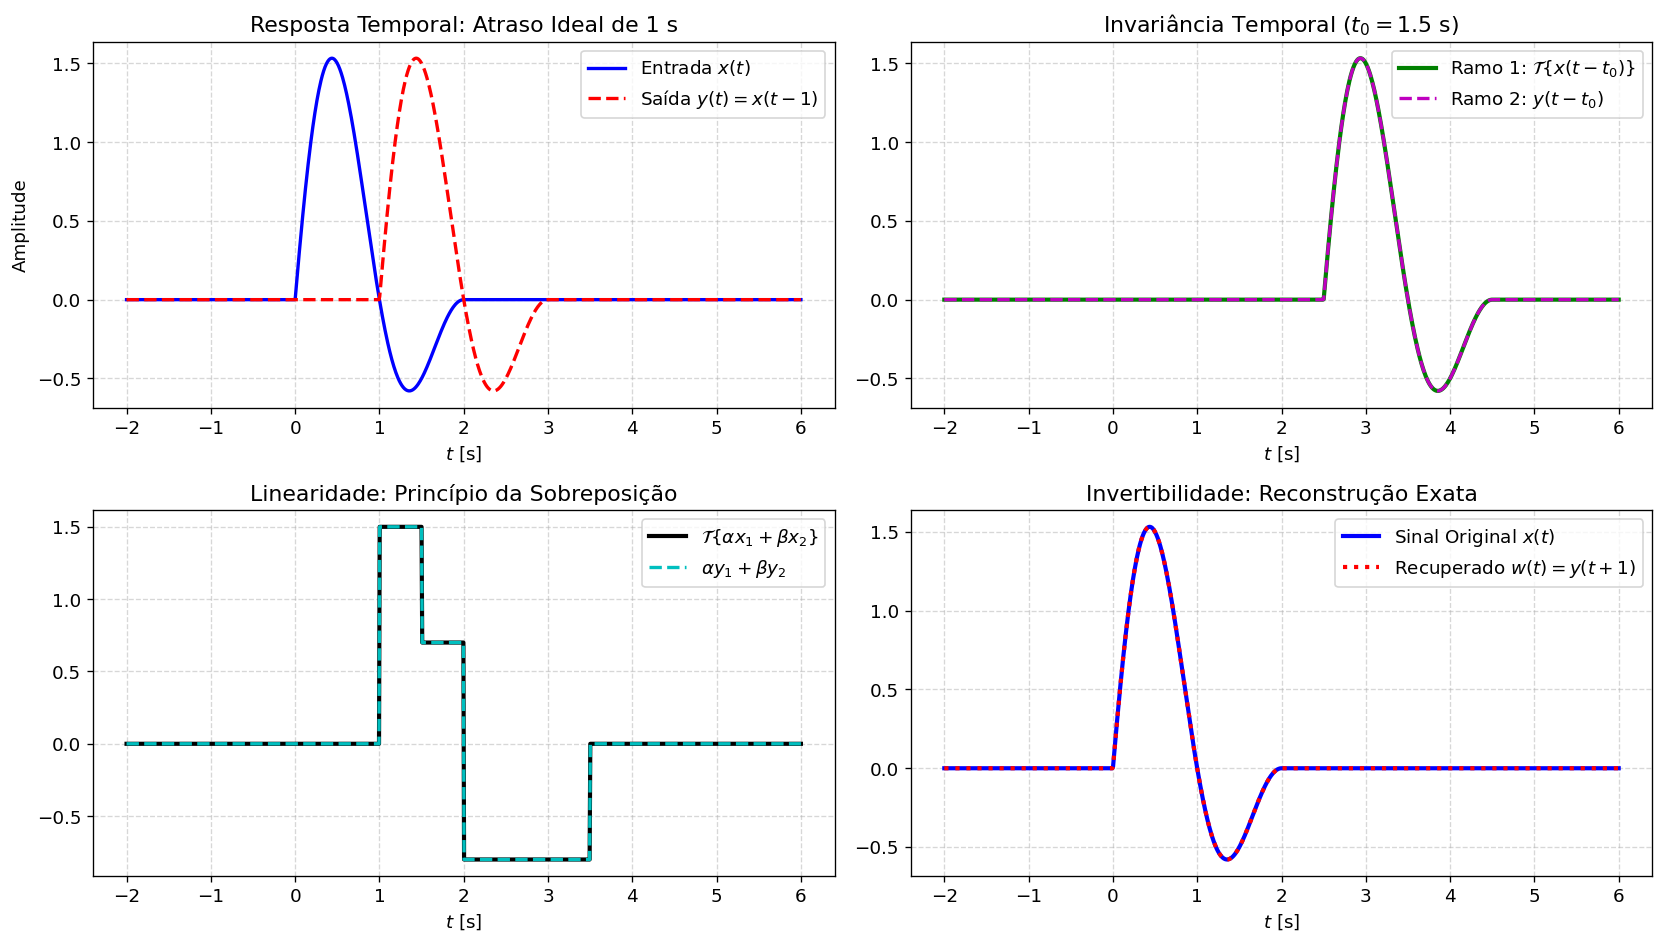

[Exercício 6a] Erro no teste de Invariância Temporal: 0.00e+00 -> INVARIANTE


In [2]:
# ====================================================================
# SIMULAÇÃO COMPUTACIONAL — Exercício 6 a): y(t) = x(t - 1)
# ====================================================================

# Base de tempo contínua simulada
t = np.linspace(-2, 6, 1000)

# 1. Definição do sinal de entrada (pulso assimétrico para evidenciar atrasos)
def pulso_entrada(tau):
    return np.where((tau >= 0) & (tau <= 2), (2.0 - tau) * np.sin(np.pi * tau), 0.0)

x = pulso_entrada(t)

# 2. Definição do Sistema: y(t) = x(t - 1)
def sistema_atraso(func_sinal, t_vec, delay=1.0):
    return func_sinal(t_vec - delay)

y = sistema_atraso(pulso_entrada, t, delay=1.0)

# 3. Teste de Invariância Temporal (Deslocamento t0 = 1.5 s)
t0 = 1.5
# Ramo 1: Atrasar a entrada e aplicar o sistema
x_deslocado = lambda tau: pulso_entrada(tau - t0)
y_ramo1 = sistema_atraso(x_deslocado, t, delay=1.0)

# Ramo 2: Atrasar a saída original por t0
y_ramo2 = sistema_atraso(pulso_entrada, t - t0, delay=1.0)

# 4. Teste do Sistema Inverso: w(t) = y(t + 1)
w_recuperado = sistema_atraso(lambda tau: sistema_atraso(pulso_entrada, tau, delay=1.0), t, delay=-1.0)

# --- Visualização Gráfica ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Subplot 1: Entrada vs Saída
axs[0, 0].plot(t, x, 'b-', lw=2, label=r'Entrada $x(t)$')
axs[0, 0].plot(t, y, 'r--', lw=2, label=r'Saída $y(t) = x(t-1)$')
axs[0, 0].set_title('Resposta Temporal: Atraso Ideal de 1 s')
axs[0, 0].set_xlabel(r'$t$ [s]')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].legend()

# Subplot 2: Verificação da Invariância Temporal
axs[0, 1].plot(t, y_ramo1, 'g-', lw=2.5, label=r'Ramo 1: $\mathcal{T}\{x(t-t_0)\}$')
axs[0, 1].plot(t, y_ramo2, 'm--', lw=2, label=r'Ramo 2: $y(t-t_0)$')
axs[0, 1].set_title(f'Invariância Temporal ($t_0 = {t0}\\text{{ s}}$)')
axs[0, 1].set_xlabel(r'$t$ [s]')
axs[0, 1].legend()

# Subplot 3: Verificação de Linearidade
alpha, beta = 1.5, -0.8
x1_func = lambda tau: np.where((tau >= 0) & (tau <= 1), 1.0, 0.0)
x2_func = lambda tau: np.where((tau >= 0.5) & (tau <= 2.5), 1.0, 0.0)
x_comb = lambda tau: alpha * x1_func(tau) + beta * x2_func(tau)

y_linear_ramo1 = sistema_atraso(x_comb, t, 1.0)
y_linear_ramo2 = alpha * sistema_atraso(x1_func, t, 1.0) + beta * sistema_atraso(x2_func, t, 1.0)

axs[1, 0].plot(t, y_linear_ramo1, 'k-', lw=2.5, label=r'$\mathcal{T}\{\alpha x_1 + \beta x_2\}$')
axs[1, 0].plot(t, y_linear_ramo2, 'c--', lw=2, label=r'$\alpha y_1 + \beta y_2$')
axs[1, 0].set_title('Linearidade: Princípio da Sobreposição')
axs[1, 0].set_xlabel(r'$t$ [s]')
axs[1, 0].legend()

# Subplot 4: Invertibilidade
axs[1, 1].plot(t, x, 'b-', lw=2.5, label=r'Sinal Original $x(t)$')
axs[1, 1].plot(t, w_recuperado, 'r:', lw=2.5, label=r'Recuperado $w(t) = y(t+1)$')
axs[1, 1].set_title('Invertibilidade: Reconstrução Exata')
axs[1, 1].set_xlabel(r'$t$ [s]')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

erro_ti = np.max(np.abs(y_ramo1 - y_ramo2))
print(f"[Exercício 6a] Erro no teste de Invariância Temporal: {erro_ti:.2e} -> INVARIANTE")


---
## Exercício 6 b)
### Sistema: $$y(t) = \int_{-\infty}^t x(\tau) \, d\tau$$
*(Integrador Contínuo / Acumulador de Carga/Energia)*

---

### Resolução Analítica Passo a Passo

#### i. Memória
* A saída no instante $t_0$ é dada por $y(t_0) = \int_{-\infty}^{t_0} x(\tau) d\tau$.
* Depende do histórico acumulado de todos os valores da entrada $x(\tau)$ desde $\tau = -\infty$ até $\tau = t_0$.
* **Classificação**: **COM MEMÓRIA (Dinâmico)**.

#### ii. Causalidade
* Os limites de integração são $\tau \in (-\infty, t]$.
* Para qualquer instante de observação $t$, todos os instantes $\tau$ considerados satisfazem $\tau \le t$ (passado e presente). Não há qualquer dependência de valores para $\tau > t$.
* **Classificação**: **CAUSAL**.

#### iii. Invariância Temporal
1. **Ramo 1 (Atraso na entrada por $t_0$)**:
   Seja $x_1(t) = x(t - t_0)$. A saída correspondente é:
   $$y_1(t) = \int_{-\infty}^t x_1(\tau) \, d\tau = \int_{-\infty}^t x(\tau - t_0) \, d\tau$$
   Mudança de variável: seja $\lambda = \tau - t_0 \implies d\lambda = d\tau$.  
   Limites: quando $\tau = -\infty \implies \lambda = -\infty$; quando $\tau = t \implies \lambda = t - t_0$.
   $$y_1(t) = \int_{-\infty}^{t - t_0} x(\lambda) \, d\lambda$$
2. **Ramo 2 (Atraso na saída original)**:
   Atrasando a saída $y(t) = \int_{-\infty}^t x(\tau) d\tau$ por $t_0$:
   $$y(t - t_0) = \int_{-\infty}^{t - t_0} x(\tau) \, d\tau$$
3. Como $y_1(t) \equiv y(t - t_0)$:
* **Classificação**: **INVARIANTE NO TEMPO (TI)**. *(Resposta impulsional $h(t) = \int_{-\infty}^t \delta(\tau) d\tau = u(t)$).*

#### iv. Linearidade
Pela linearidade da operação de integração de Riemann:
$$y_3(t) = \int_{-\infty}^t [\alpha x_1(\tau) + \beta x_2(\tau)] \, d\tau = \alpha \int_{-\infty}^t x_1(\tau) \, d\tau + \beta \int_{-\infty}^t x_2(\tau) \, d\tau = \alpha y_1(t) + \beta y_2(t)$$
* **Classificação**: **LINEAR**.

#### v. Estabilidade (BIBO)
* Para ser BIBO-estável, qualquer entrada limitada deve originar uma saída limitada.
* **Contra-exemplo formal**:
  - Seja o sinal de entrada o degrau unitário $x(t) = u(t)$, que é limitado: $|x(t)| \le 1, \forall t$.
  - A saída obtida é:
    $$y(t) = \int_{-\infty}^t u(\tau) \, d\tau = \begin{cases} 0, & t < 0 \\ \int_0^t 1 \, d\tau = t, & t \ge 0 \end{cases} = t \cdot u(t) = r(t) \quad (\text{Rampa Unitária})$$
  - Quando $t \to +\infty$, $y(t) = t \to +\infty$ (a amplitude cresce indefinidamente).
* **Classificação**: **NÃO ESTÁVEL (Instável BIBO)**.

#### vi. Invertibilidade
* Pelo **Teorema Fundamental do Cálculo**, a operação inversa da integração é a derivação:
  $$w(t) = \frac{d}{dt} y(t) = \frac{d}{dt} \left( \int_{-\infty}^t x(\tau) \, d\tau \right) = x(t)$$
* O sistema inverso existe e é o derivador ideal $\mathcal{T}^{-1}\{y(t)\} = \frac{dy(t)}{dt}$.
* **Classificação**: **INVERTÍVEL**.

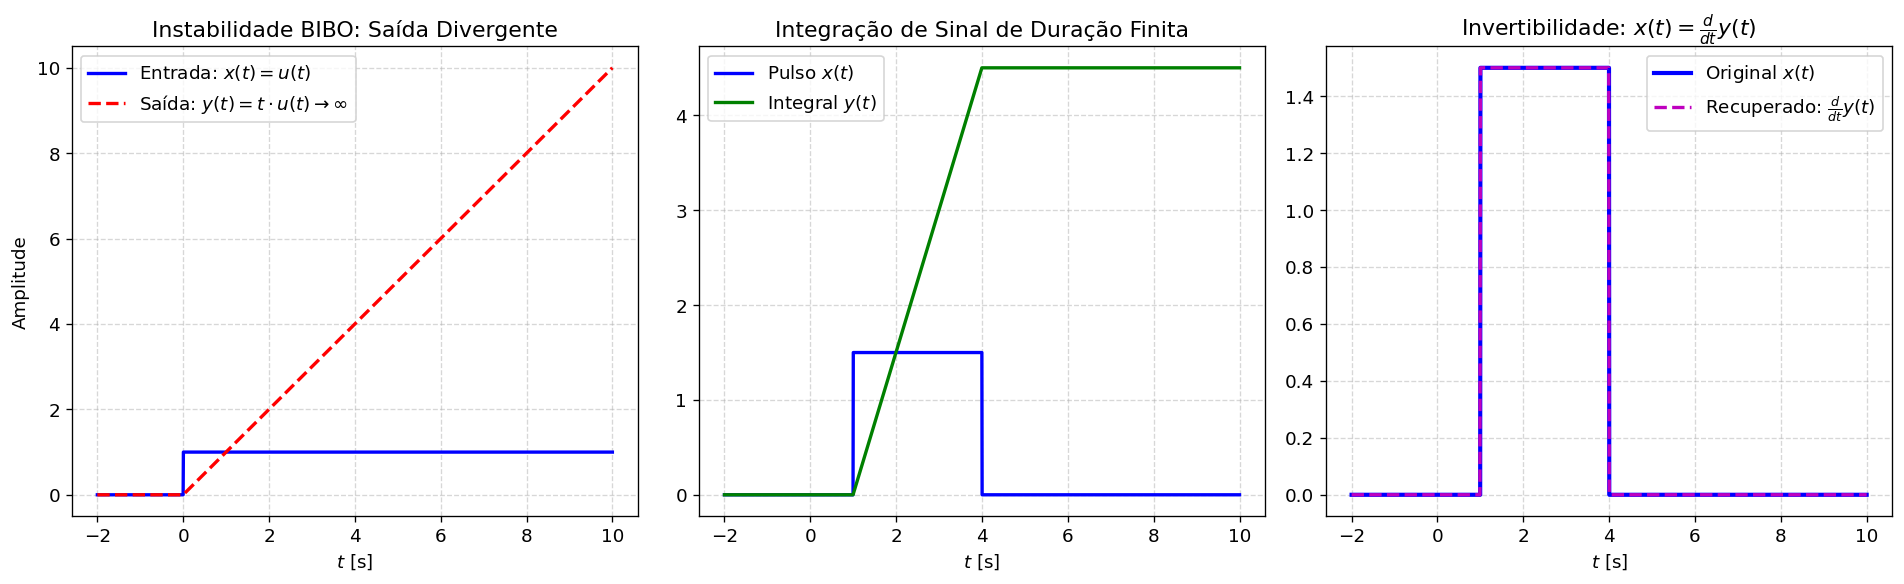

In [2]:
# ====================================================================
# SIMULAÇÃO COMPUTACIONAL — Exercício 6 b): y(t) = \int_{-\infty}^t x(\tau) d\tau
# ====================================================================

# Base de tempo
t = np.linspace(-2, 10, 2000)
dt = t[1] - t[0]

# 1. Demonstração de Instabilidade BIBO com entrada limitada u(t)
x_degrau = np.where(t >= 0, 1.0, 0.0)
y_rampa = np.cumsum(x_degrau) * dt  # Integração numérica

# 2. Resposta a um pulso quadrado de energia finita
x_pulso = np.where((t >= 1) & (t <= 4), 1.5, 0.0)
y_pulso = np.cumsum(x_pulso) * dt

# 3. Teste do Sistema Inverso: Derivação dy/dt
x_recuperado = np.gradient(y_pulso, dt)

# --- Visualização Gráfica ---
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Prova de Instabilidade BIBO
axs[0].plot(t, x_degrau, 'b-', lw=2, label=r'Entrada: $x(t) = u(t)$')
axs[0].plot(t, y_rampa, 'r--', lw=2, label=r'Saída: $y(t) = t \cdot u(t) \to \infty$')
axs[0].set_title('Instabilidade BIBO: Saída Divergente')
axs[0].set_xlabel(r'$t$ [s]')
axs[0].set_ylabel('Amplitude')
axs[0].legend()

# Subplot 2: Resposta ao Pulso Finito
axs[1].plot(t, x_pulso, 'b-', lw=2, label=r'Pulso $x(t)$')
axs[1].plot(t, y_pulso, 'g-', lw=2, label=r'Integral $y(t)$')
axs[1].set_title('Integração de Sinal de Duração Finita')
axs[1].set_xlabel(r'$t$ [s]')
axs[1].legend()

# Subplot 3: Recuperação com o Sistema Inverso (Derivador)
axs[2].plot(t, x_pulso, 'b-', lw=2.5, label=r'Original $x(t)$')
axs[2].plot(t, x_recuperado, 'm--', lw=2, label=r'Recuperado: $\frac{d}{dt}y(t)$')
axs[2].set_title(r'Invertibilidade: $x(t) = \frac{d}{dt}y(t)$')
axs[2].set_xlabel(r'$t$ [s]')
axs[2].legend()

plt.tight_layout()
plt.show()


---
## Exercício 6 g)
### Sistema: $$y[n] = n \, x[n]$$
*(Ganho Variante no Tempo Discreto / Modulador com Rampa Linear)*

---

### Resolução Analítica Passo a Passo

#### i. Memória
* Para calcular o valor da saída no índice $n_0$, $y[n_0] = n_0 x[n_0]$, necessitamos **apenas e só** da amostra de entrada no mesmo índice presente $x[n_0]$.
* Não depende de qualquer amostra passada ($n < n_0$) ou futura ($n > n_0$).
* **Classificação**: **SEM MEMÓRIA (Estático)**.

#### ii. Causalidade
* Sendo um sistema sem memória, depende unicamente do instante presente $n$. Logo, não depende de valores futuros ($n > n_0$).
* **Classificação**: **CAUSAL**.

#### iii. Invariância Temporal
Aplicamos o teste dos dois ramos com deslocamento inteiro $n_0 \neq 0$:
1. **Ramo 1 (Atraso na entrada)**:
   Seja $x_1[n] = x[n - n_0]$. A saída do sistema para esta entrada é:
   $$y_1[n] = \mathcal{T}\{x_1[n]\} = n \, x_1[n] = n \, x[n - n_0]$$
2. **Ramo 2 (Atraso na saída original)**:
   Atrasando a saída original $y[n] = n x[n]$ em $n_0$ amostras (substituindo todas as variáveis $n$ por $n - n_0$):
   $$y[n - n_0] = (n - n_0) \, x[n - n_0]$$
3. Comparação:
   $$y_1[n] = n x[n - n_0] \quad \neq \quad y[n - n_0] = (n - n_0) x[n - n_0]$$
   *(Exemplo numérico: para $n_0 = 2$, no índice $n = 3$: $y_1[3] = 3 x[1]$, mas $y[3-2] = y[1] = 1 x[1]$. Como $3 x[1] \neq 1 x[1]$, a resposta difere).*
* **Classificação**: **VARIANTE NO TEMPO (TV)**.

#### iv. Linearidade
Seja $x_3[n] = \alpha x_1[n] + \beta x_2[n]$:
$$y_3[n] = n \, x_3[n] = n [\alpha x_1[n] + \beta x_2[n]] = \alpha (n x_1[n]) + \beta (n x_2[n]) = \alpha y_1[n] + \beta y_2[n]$$
* **Classificação**: **LINEAR**.

#### v. Estabilidade (BIBO)
* **Contra-exemplo formal**:
  - Seja a entrada limitada $x[n] = u[n]$ (onde $|x[n]| \le 1, \forall n$).
  - A saída é:
    $$y[n] = n \cdot u[n] = \{0, 1, 2, 3, 4, \dots, n, \dots\}$$
  - Quando $n \to +\infty$, a saída $y[n] = n \to +\infty$ diverge.
* **Classificação**: **NÃO ESTÁVEL (Instável BIBO)**.

#### vi. Invertibilidade
* Para ser invertível, a transformação deve ser injetiva (entradas diferentes geram saídas diferentes).
* Avaliemos o instante $n = 0$:
  $$y[0] = 0 \cdot x[0] = 0, \quad \forall x[0] \in \mathbb{R}$$
* O valor de $x[0]$ é multiplicado por zero, perdendo-se irremediavelmente.
* **Contra-exemplo de Injetividade**:
  - Seja $x_1[n] = 5 \delta[n] \implies y_1[n] = n \cdot 5 \delta[n] = 0, \forall n$.
  - Seja $x_2[n] = 0, \forall n \implies y_2[n] = 0, \forall n$.
  - Embora $x_1[n] \neq x_2[n]$, temos $y_1[n] \equiv y_2[n] \equiv 0$. É impossível saber se $x[0]$ valia $5$, $0$ ou outro número qualquer.
* **Classificação**: **NÃO INVERTÍVEL**.

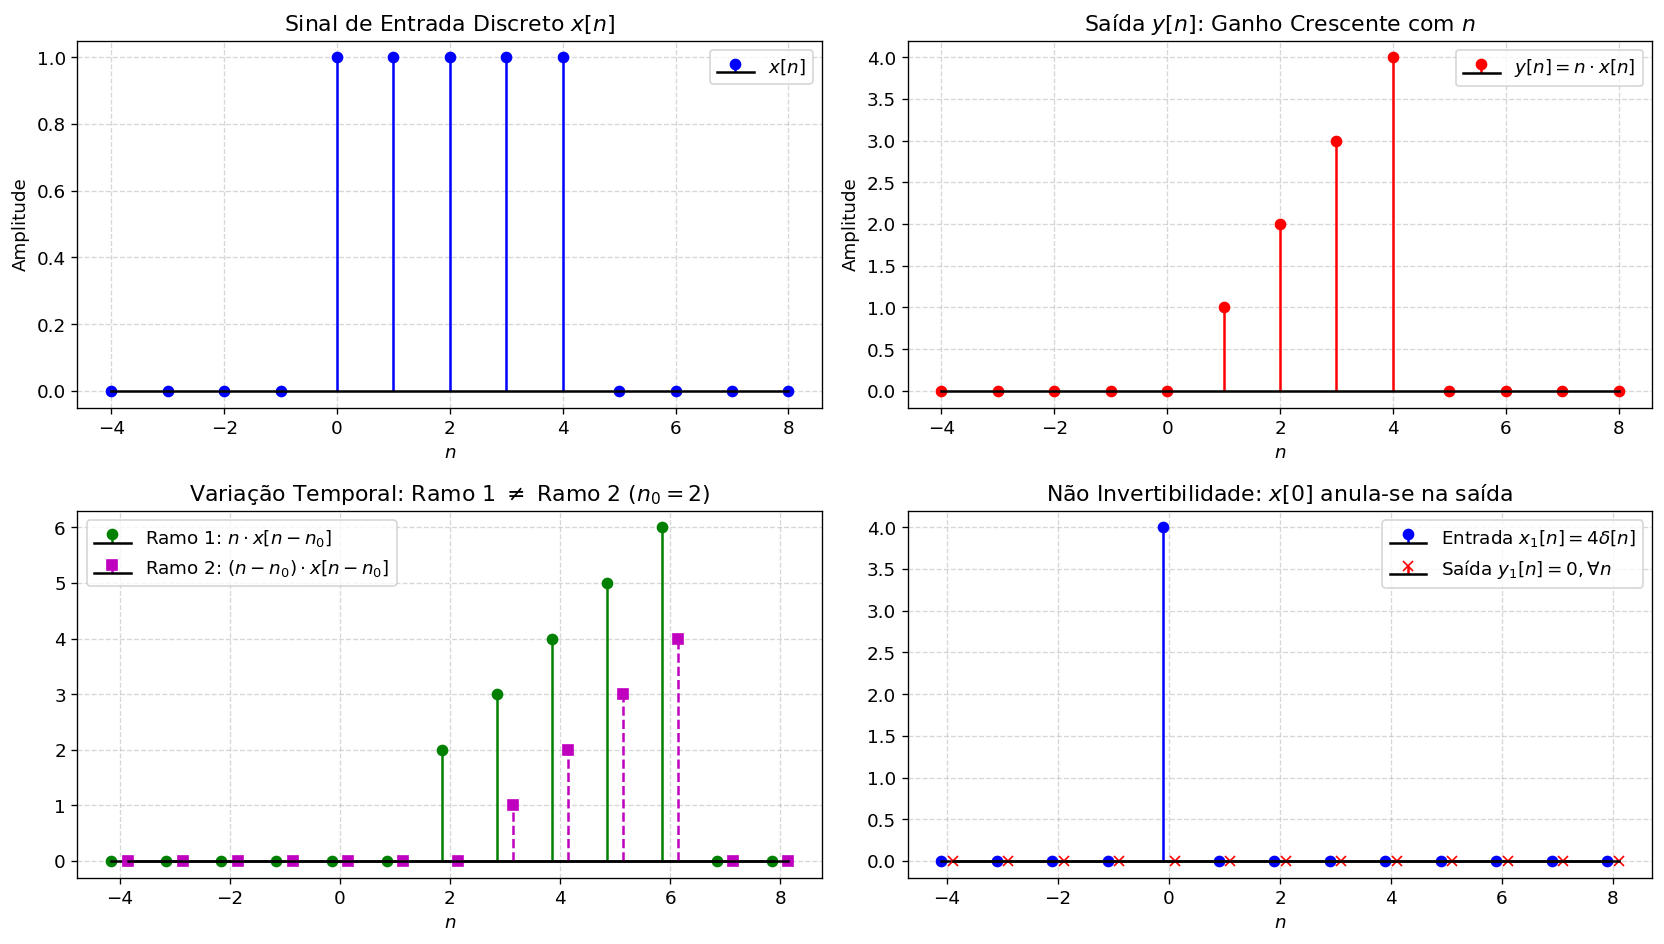

[Exercício 6g] Diferença máxima entre Ramos 1 e 2: 2.0 != 0 -> VARIANTE NO TEMPO


In [3]:
# ====================================================================
# SIMULAÇÃO COMPUTACIONAL — Exercício 6 g): y[n] = n * x[n]
# ====================================================================

# Eixo discreto
n = np.arange(-4, 9)

# 1. Definição do sinal de entrada discreto (pulso de 0 a 4)
x = np.where((n >= 0) & (n <= 4), 1.0, 0.0)

# 2. Definição do Sistema
y = n * x

# 3. Teste de Variação Temporal (Deslocamento n0 = 2)
n0 = 2
x_atrasado = np.where(((n - n0) >= 0) & ((n - n0) <= 4), 1.0, 0.0)

y_ramo1 = n * x_atrasado                # Ramo 1: T{x[n-n0]} = n * x[n-n0]
y_ramo2 = (n - n0) * x_atrasado         # Ramo 2: y[n-n0] = (n-n0) * x[n-n0]

# --- Visualização Gráfica ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Subplot 1: Sinal de Entrada
axs[0, 0].stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$x[n]$')
axs[0, 0].set_title('Sinal de Entrada Discreto $x[n]$')
axs[0, 0].set_xlabel(r'$n$')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].legend()

# Subplot 2: Saída
axs[0, 1].stem(n, y, linefmt='r-', markerfmt='ro', basefmt='k-', label=r'$y[n] = n \cdot x[n]$')
axs[0, 1].set_title('Saída $y[n]$: Ganho Crescente com $n$')
axs[0, 1].set_xlabel(r'$n$')
axs[0, 1].set_ylabel('Amplitude')
axs[0, 1].legend()

# Subplot 3: Prova Gráfica de Variação Temporal (Ramo 1 != Ramo 2)
axs[1, 0].stem(n - 0.15, y_ramo1, linefmt='g-', markerfmt='go', basefmt='k-', label=r'Ramo 1: $n \cdot x[n-n_0]$')
axs[1, 0].stem(n + 0.15, y_ramo2, linefmt='m--', markerfmt='ms', basefmt='k-', label=r'Ramo 2: $(n-n_0) \cdot x[n-n_0]$')
axs[1, 0].set_title(f'Variação Temporal: Ramo 1 $\\neq$ Ramo 2 ($n_0 = {n0}$)')
axs[1, 0].set_xlabel(r'$n$')
axs[1, 0].legend()

# Subplot 4: Perda de Informação em n=0 (Não Invertibilidade)
x1_impulso = np.zeros_like(n, dtype=float)
x1_impulso[n == 0] = 4.0  # Impulso 4*delta[n]
y1_impulso = n * x1_impulso

axs[1, 1].stem(n - 0.1, x1_impulso, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'Entrada $x_1[n] = 4\delta[n]$')
axs[1, 1].stem(n + 0.1, y1_impulso, linefmt='r--', markerfmt='rx', basefmt='k-', label=r'Saída $y_1[n] = 0, \forall n$')
axs[1, 1].set_title(r'Não Invertibilidade: $x[0]$ anula-se na saída')
axs[1, 1].set_xlabel(r'$n$')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"[Exercício 6g] Diferença máxima entre Ramos 1 e 2: {np.max(np.abs(y_ramo1 - y_ramo2))} != 0 -> VARIANTE NO TEMPO")


---
## Exercício 6 h)
### Sistema: $$y[n] = x[n] \, x[-n]$$
*(Produto com Reversão Temporal / Autoproduto Simétrico)*

---

### Resolução Analítica Passo a Passo

#### i. Memória
* Para determinar a saída num instante genérico, por exemplo $n_0 = 2$:
  $$y[2] = x[2] \cdot x[-2]$$
* A saída em $n=2$ requer o conhecimento de $x[-2]$ (valor passado).
* Para $n=-2$, $y[-2] = x[-2] \cdot x[2]$, que requer o conhecimento de $x[2]$ (valor futuro).
* Como não depende exclusivamente do instante presente:
* **Classificação**: **COM MEMÓRIA (Dinâmico)**.

#### ii. Causalidade
* Para $n < 0$, a saída depende de $x[-n]$, onde $-n > 0$, que é uma amostra estritamente **futura**.
* Exemplo concreto: Em $n = -3$, $y[-3] = x[-3] \cdot x[3]$, que necessita de $x[3]$ ($3$ amostras no futuro em relação ao instante $n=-3$).
* **Classificação**: **NÃO CAUSAL (Antecipatório)**.

#### iii. Invariância Temporal
Aplicamos o teste dos dois ramos com deslocamento inteiro $n_0 \neq 0$:
1. **Ramo 1 (Atraso na entrada por $n_0$)**:
   Seja $x_1[n] = x[n - n_0]$. A saída correspondente é:
   $$y_1[n] = \mathcal{T}\{x_1[n]\} = x_1[n] \, x_1[-n] = x[n - n_0] \, x[-n - n_0]$$
2. **Ramo 2 (Atraso na saída original)**:
   Atrasando a saída $y[n] = x[n]x[-n]$ em $n_0$ (substituindo todos os $n$ por $n - n_0$):
   $$y[n - n_0] = x[n - n_0] \, x[-(n - n_0)] = x[n - n_0] \, x[-n + n_0]$$
3. Comparação:
   $$x[-n - n_0] \quad \neq \quad x[-n + n_0] \quad (\text{para } n_0 \neq 0)$$
   Portanto, $y_1[n] \neq y[n - n_0]$.
* **Classificação**: **VARIANTE NO TEMPO (TV)**.

#### iv. Linearidade
Testamos a condição de homogeneidade $\mathcal{T}\{\alpha x[n]\} = \alpha \mathcal{T}\{x[n]\}$:
* Seja $x_1[n] = \alpha x[n]$. A saída do sistema para esta entrada é:
  $$y_1[n] = x_1[n] \, x_1[-n] = (\alpha x[n]) \cdot (\alpha x[-n]) = \alpha^2 x[n] x[-n] = \alpha^2 y[n]$$
* Se o sistema fosse linear, a saída deveria ser $\alpha y[n]$. No entanto, obtém-se $\alpha^2 y[n]$.
* Para qualquer $\alpha \neq 0, 1$ (ex: $\alpha = 2 \implies y_1 = 4 y \neq 2 y$), a homogeneidade falha.
* **Classificação**: **NÃO LINEAR**.

#### v. Estabilidade (BIBO)
* Seja uma entrada limitada qualquer: $|x[n]| \le M_x < \infty, \forall n$.
* Avaliando o módulo da saída:
  $$|y[n]| = |x[n] \cdot x[-n]| = |x[n]| \cdot |x[-n]| \le M_x \cdot M_x = M_x^2 < \infty$$
* Visto que $M_x < \infty \implies M_y = M_x^2 < \infty$, toda e qualquer entrada limitada produz garantidamente uma saída limitada.
* **Classificação**: **ESTÁVEL (BIBO)**.

#### vi. Invertibilidade
* **Contra-exemplo 1 (Simetria de Sinal)**:
  - Seja $x_2[n] = -x_1[n]$.
  - A saída correspondente é:
    $$y_2[n] = (-x_1[n]) \cdot (-x_1[-n]) = x_1[n] \, x_1[-n] = y_1[n]$$
  - As entradas $x_1[n]$ e $-x_1[n]$ (claramente distintas se $x \neq 0$) produzem exatamente a mesma saída $y[n]$.
* **Contra-exemplo 2 (Perda da componente ímpar)**:
  - Note que $y[-n] = x[-n] x[-(-n)] = x[-n] x[n] = y[n]$. A saída é **obrigatoriamente um sinal par**, perdendo a informação de fase/assimetria da entrada.
* **Classificação**: **NÃO INVERTÍVEL**.

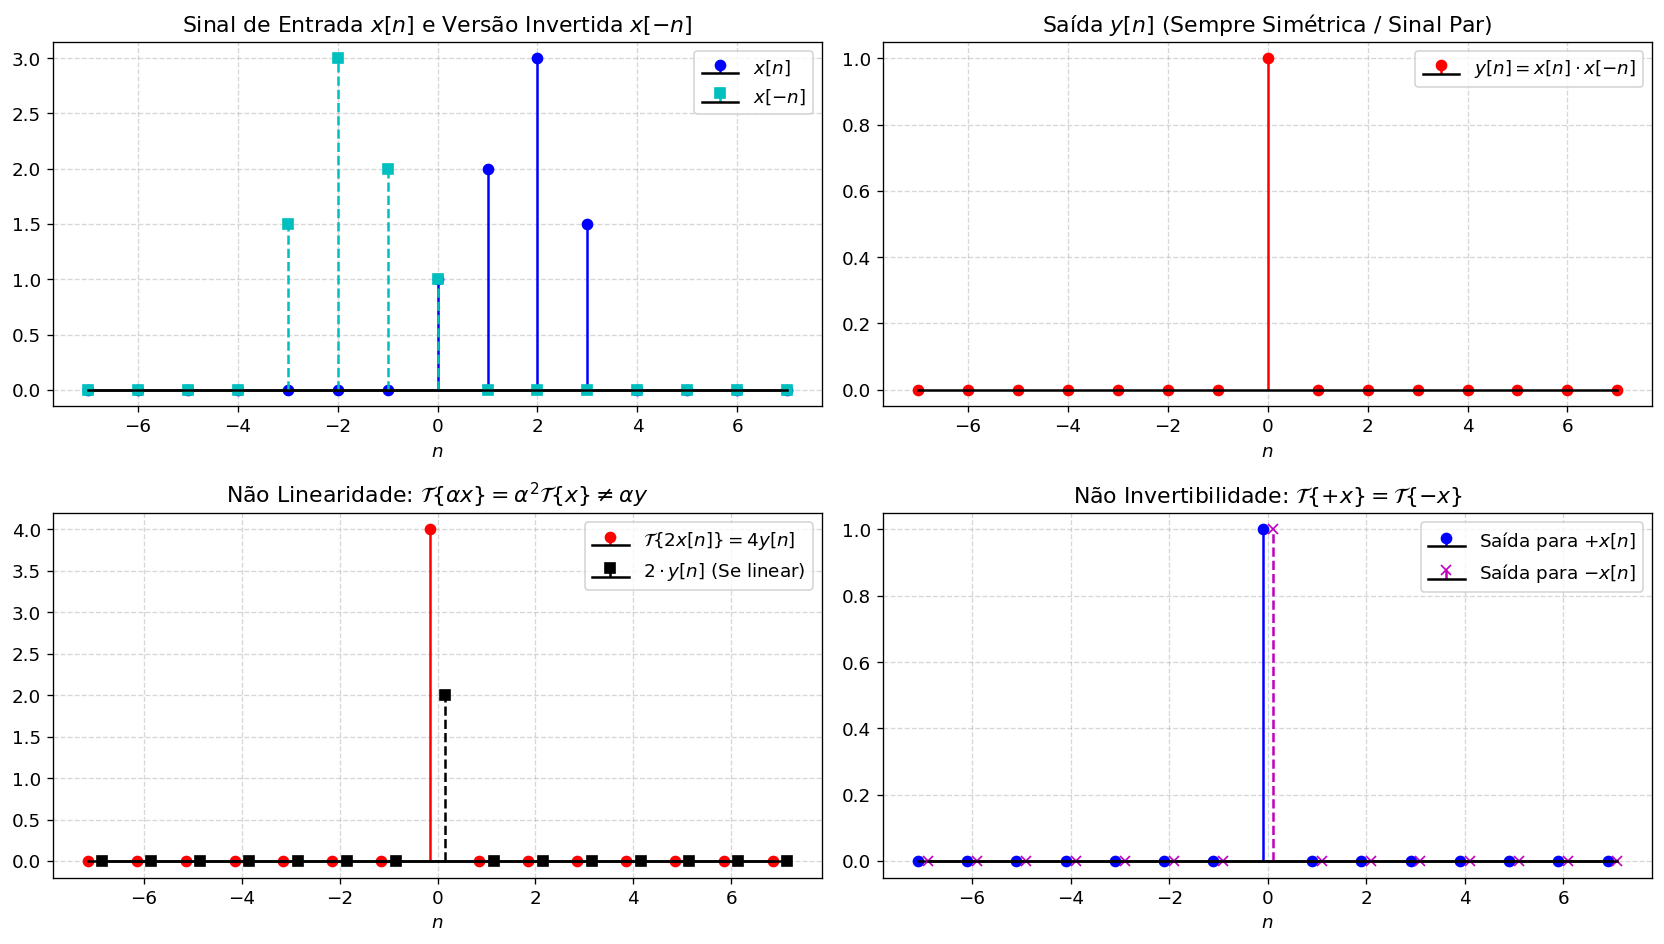

[Exercício 6h] Razão de amplitude y(2x)/y(x) em n=0: 4.0 (esperado 4.0 -> NÃO LINEAR)


In [4]:
# ====================================================================
# SIMULAÇÃO COMPUTACIONAL — Exercício 6 h): y[n] = x[n] * x[-n]
# ====================================================================

# Eixo temporal discreto simétrico
n = np.arange(-7, 8)

# 1. Definição de sinal de teste assimétrico
x = np.zeros_like(n, dtype=float)
x[n == 0] = 1.0
x[n == 1] = 2.0
x[n == 2] = 3.0
x[n == 3] = 1.5

# Função para inverter sinal no tempo: x[-n]
def inverter_tempo(sinal, n_vec):
    indices = [np.where(n_vec == -k)[0][0] for k in n_vec]
    return sinal[indices]

x_invertido = inverter_tempo(x, n)
y = x * x_invertido

# 2. Teste de Não-Linearidade (Escalar por alpha = 2)
alpha = 2.0
x_alpha = alpha * x
y_alpha = x_alpha * inverter_tempo(x_alpha, n)
y_esperado_se_linear = alpha * y

# 3. Teste de Não-Invertibilidade: Entrada -x[n]
x_neg = -x
y_neg = x_neg * inverter_tempo(x_neg, n)

# --- Visualização Gráfica ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Subplot 1: Sinais x[n] e x[-n]
axs[0, 0].stem(n, x, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$x[n]$')
axs[0, 0].stem(n, x_invertido, linefmt='c--', markerfmt='cs', basefmt='k-', label=r'$x[-n]$')
axs[0, 0].set_title('Sinal de Entrada $x[n]$ e Versão Invertida $x[-n]$')
axs[0, 0].set_xlabel(r'$n$')
axs[0, 0].legend()

# Subplot 2: Saída y[n] (Par)
axs[0, 1].stem(n, y, linefmt='r-', markerfmt='ro', basefmt='k-', label=r'$y[n] = x[n] \cdot x[-n]$')
axs[0, 1].set_title('Saída $y[n]$ (Sempre Simétrica / Sinal Par)')
axs[0, 1].set_xlabel(r'$n$')
axs[0, 1].legend()

# Subplot 3: Prova de Não-Linearidade (Quadrática)
axs[1, 0].stem(n - 0.15, y_alpha, linefmt='r-', markerfmt='ro', basefmt='k-', label=r'$\mathcal{T}\{2 x[n]\} = 4 y[n]$')
axs[1, 0].stem(n + 0.15, y_esperado_se_linear, linefmt='k--', markerfmt='ks', basefmt='k-', label=r'$2 \cdot y[n]$ (Se linear)')
axs[1, 0].set_title(r'Não Linearidade: $\mathcal{T}\{\alpha x\} = \alpha^2 \mathcal{T}\{x\} \neq \alpha y$')
axs[1, 0].set_xlabel(r'$n$')
axs[1, 0].legend()

# Subplot 4: Prova de Não Invertibilidade
axs[1, 1].stem(n - 0.1, y, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'Saída para $+x[n]$')
axs[1, 1].stem(n + 0.1, y_neg, linefmt='m--', markerfmt='mx', basefmt='k-', label=r'Saída para $-x[n]$')
axs[1, 1].set_title(r'Não Invertibilidade: $\mathcal{T}\{+x\} = \mathcal{T}\{-x\}$')
axs[1, 1].set_xlabel(r'$n$')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"[Exercício 6h] Razão de amplitude y(2x)/y(x) em n=0: {y_alpha[n==0][0] / y[n==0][0]:.1f} (esperado 4.0 -> NÃO LINEAR)")


---
## 3. Quadro Síntese de Classificação dos Sistemas

A tabela abaixo consolida e compara as classificações obtidas para cada um dos quatro sistemas analisados:

| Alínea | Expressão do Sistema | Domínio | Memória | Causalidade | Invariância Temporal | Linearidade | Estabilidade (BIBO) | Invertibilidade |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **a)** | $y(t) = x(t-1)$ | TC | **Com Memória** | **Causal** | **Invariante (TI)** | **Linear** | **Estável** | **Invertível** ($w(t)=y(t+1)$) |
| **b)** | $y(t) = \int_{-\infty}^t x(\tau)d\tau$ | TC | **Com Memória** | **Causal** | **Invariante (TI)** | **Linear** | **Instável** ($u(t) \to t u(t)$) | **Invertível** ($w(t)=\frac{dy}{dt}$) |
| **g)** | $y[n] = n \, x[n]$ | TD | **Sem Memória** | **Causal** | **Variante (TV)** | **Linear** | **Instável** ($u[n] \to n u[n]$) | **Não Invertível** ($x[0]$ perdido) |
| **h)** | $y[n] = x[n] \, x[-n]$ | TD | **Com Memória** | **Não Causal** | **Variante (TV)** | **Não Linear** | **Estável** | **Não Invertível** ($\pm x \to y$) |

---

## Notas a recordar

1. **Relação entre Memória e Causalidade**:
   - Todo o sistema **Sem Memória** é garantidamente **Causal** (pois a saída em $t_0$ só depende de $x(t_0)$).
   - O recíproco não é verdadeiro: um sistema pode ter memória e ser perfeitamente causal (ex: alínea *a* e *b*).
2. **Identificação Rápida de Sistemas Variantes no Tempo**:
   - Se a variável temporal independente $t$ ou $n$ figurar explicitamente como coeficiente (ex: $n x[n]$, $\cos(\omega t) x(t)$) ou com inversão/escala temporal (ex: $x[-n]$, $x(2t)$), o sistema é **Variante no Tempo**.
3. **Linearidade**:
   - Verifique sempre a condição necessária de repouso: se $x = 0 \implies y = 0$.
   - A presença de termos independentes ($+C$), potências ($x^2$), produtos de sinais ($x[n]x[-n]$) ou módulos ($|x|$) invalida a linearidade.
4. **Metodologia para Estabilidade BIBO**:
   - Para provar que é estável: majorar $|y| \le M_y$ a partir da hipótese $|x| \le M_x < \infty$.
   - Para provar que é instável: basta encontrar **um único contra-exemplo** (tipicamente $x = u(t)$ ou $x = u[n]$).
5. **Invertibilidade**:
   - A perda de informação ocorre frequentemente quando existe multiplicação por zero ($n=0$ em $n x[n]$), operações não injectivas como módulo ou quadrado, ou quando sinais de entrada simétricos $\pm x$ geram a mesma resposta.